# 02 — Exploratory Data Analysis & Asset Trajectory Profiling

**7030DATSCI · Event-Driven Market Impact & Causal Prediction Pipeline**  
**Author:** Ibrahim Haroun · **LJMU 2025–2026** · **Version:** 3.0 (Full Reproducible Pipeline)

---

## Objectives

Explore and validate all multi-source market, macroeconomic, political, and geopolitical datasets generated in `01_data_collection.ipynb`:

1. **Primary Asset Trajectory (SPY):** Rebase the S&P 500 benchmark to $t_0 = 100.0$ (Jan 2015) to evaluate long-term market growth and structural regime shocks.
2. **SPY Return & Heavy-Tail Profiling:** Inspect continuous log-return density, skewness, excess kurtosis, and departure from normality.
3. **VIX Market Regimes & Yield Spread:** Profile market uncertainty spikes ($\text{VIX} \ge 30.0$) and Treasury yield curve inversions ($\text{10Y} - \text{2Y} \le 0$).
4. **Time-Series Stationarity Audit:** Apply joint Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests across core continuous predictors.
5. **Multi-Source Event Density & Correlation Profiling:** Audit economic presidential communications, FOMC monetary policy decisions, and daily GDELT geopolitical risk metrics.

**Outputs:** Publication-quality figures saved to `reports/figures/` and audit tables saved to `reports/tables/`.

## Imports & Environment Setup
Action: Ensure all required data science, time series, and plotting libraries are loaded.

In [1]:
# ── 0. Setup, Environment Configuration, and Imports ──────────────────────────

import sys, os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sps
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore')

# Resolve project root and append to python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_collector import load_config

# Configure plotting aesthetics
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.family': 'sans-serif',
})

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Environment initialized and output directories verified.")

✓ Environment initialized and output directories verified.


## 1. Project Configuration & Environment Setup
Load YAML configurations to set global data directories and pipeline parameter boundaries.

In [2]:
# ── 1. Configuration & Path Binding ──────────────────────────────────────────

config = load_config("../config.yaml")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

print(f"Project Name : {config['project']['name']}")
print(f"Project Root : {PROJECT_ROOT}")
print(f"Raw Data Dir : {RAW_DIR}")
print(f"Figures Dir  : {FIG_DIR}")
print(f"Tables Dir   : {TABLE_DIR}")

Project Name : Causal Event-Driven Market Impact Modelling
Project Root : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
Raw Data Dir : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/raw
Figures Dir  : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures
Tables Dir   : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables


---
## 2. Dataset Ingestion & Schema Audit
Load all standardized Parquet artifacts produced by `01_data_collection.ipynb` to verify observation counts, date boundaries, and missing value counts.

In [3]:
# ── 2. Ingestion & Schema Audit ───────────────────────────────────────────────

def load_time_indexed_parquet(path, date_col="date"):
    df = pd.read_parquet(path)
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        df.index = pd.to_datetime(df.index)
    return df.sort_index()

# Load Primary Market & Return Features
spy_ohlcv    = load_time_indexed_parquet(RAW_DIR / 'spy_ohlcv.parquet')
spy_returns  = load_time_indexed_parquet(RAW_DIR / 'spy_returns.parquet')
vix          = load_time_indexed_parquet(RAW_DIR / 'vix.parquet')

# Load Macro, Event, and Calendar Datasets
macro_df     = load_time_indexed_parquet(RAW_DIR / 'macro_indicators.parquet')
fomc_df      = pd.read_parquet(RAW_DIR / 'fomc_dates.parquet')
app_docs     = pd.read_parquet(RAW_DIR / 'app_presidential_documents_economic.parquet')
gdelt_df     = load_time_indexed_parquet(RAW_DIR / 'gdelt_daily_summary.parquet')
master_df    = load_time_indexed_parquet(RAW_DIR / 'daily_modelling_calendar_v1.parquet')

print("=" * 80)
print(f"SPY Price Series  : {len(spy_ohlcv):,} rows ({spy_ohlcv.index.min().date()} → {spy_ohlcv.index.max().date()})")
print(f"SPY Return Targets: {len(spy_returns):,} rows ({spy_returns.index.min().date()} → {spy_returns.index.max().date()})")
print(f"VIX Volatility    : {len(vix):,} rows | Mean Level = {vix['vix_close'].mean():.2f}")
print(f"FRED Macro Series : {len(macro_df):,} rows × {macro_df.shape[1]} series")
print(f"FOMC Announcements: {len(fomc_df):,} events")
print(f"APP Economic Docs : {len(app_docs):,} documents")
print(f"GDELT Daily Stream: {len(gdelt_df):,} trading days")
print(f"Master Calendar   : {len(master_df):,} trading days")
print("=" * 80)

SPY Price Series  : 2,765 rows (2015-01-02 → 2025-12-30)
SPY Return Targets: 2,743 rows (2015-02-03 → 2025-12-29)
VIX Volatility    : 2,765 rows | Mean Level = 18.33
FRED Macro Series : 2,870 rows × 7 series
FOMC Announcements: 89 events
APP Economic Docs : 916 documents
GDELT Daily Stream: 4,018 trading days
Master Calendar   : 2,743 trading days


---
## 3. Primary Market Benchmark (SPY) Trajectory & Distribution

### 3a. SPY Rebased Price Growth Trajectory ($t_0 = 100.0$)
Rebase the SPY adjusted close price series to $100.0$ on the first trading day of 2015. This allows for direct growth evaluation across macroeconomic crisis points (e.g., March 2020 COVID shock, 2022 Fed rate hiking cycle) without altering log returns.

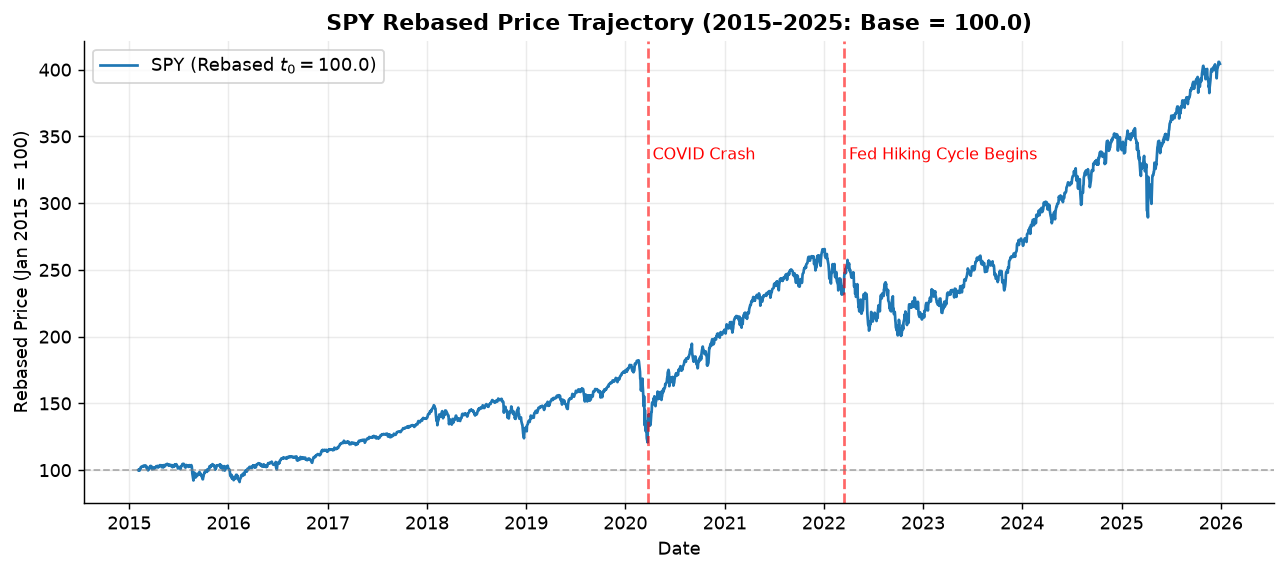

✓ Saved Figure 3a → /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/01_spy_rebased_price.png


In [4]:
# ── 3a. SPY Normalized Trajectory Plotting ────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4.5))

rebased_spy = (spy_returns['spy_close'] / spy_returns['spy_close'].iloc[0]) * 100.0

ax.plot(rebased_spy.index, rebased_spy.values, color='#1f77b4', lw=1.5, label='SPY (Rebased $t_0=100.0$)')
ax.set_ylabel('Rebased Price (Jan 2015 = 100)')
ax.set_xlabel('Date')
ax.set_title('SPY Rebased Price Trajectory (2015–2025: Base = 100.0)', fontsize=12, fontweight='bold')

# Highlight key regime events
events = {
    '2020-03-23': 'COVID Crash',
    '2022-03-16': 'Fed Hiking Cycle Begins'
}
for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    if dt in rebased_spy.index:
        ax.axvline(dt, color='red', linestyle='--', alpha=0.6)
        ax.text(dt, rebased_spy.max() * 0.82, f" {label}", color='red', fontsize=9)

ax.axhline(100, color='gray', linestyle='--', alpha=0.6, linewidth=1.0)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left')
fig.tight_layout()

fig_path = FIG_DIR / '01_spy_rebased_price.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved Figure 3a → {fig_path}")

### 3b. SPY Daily Log Return Density & Heavy-Tail Profiling
Evaluate skewness, excess kurtosis, and departure from normal distribution assumptions for daily continuous log returns ($\text{Log Return}_t = \ln(P_t / P_{t-1})$).

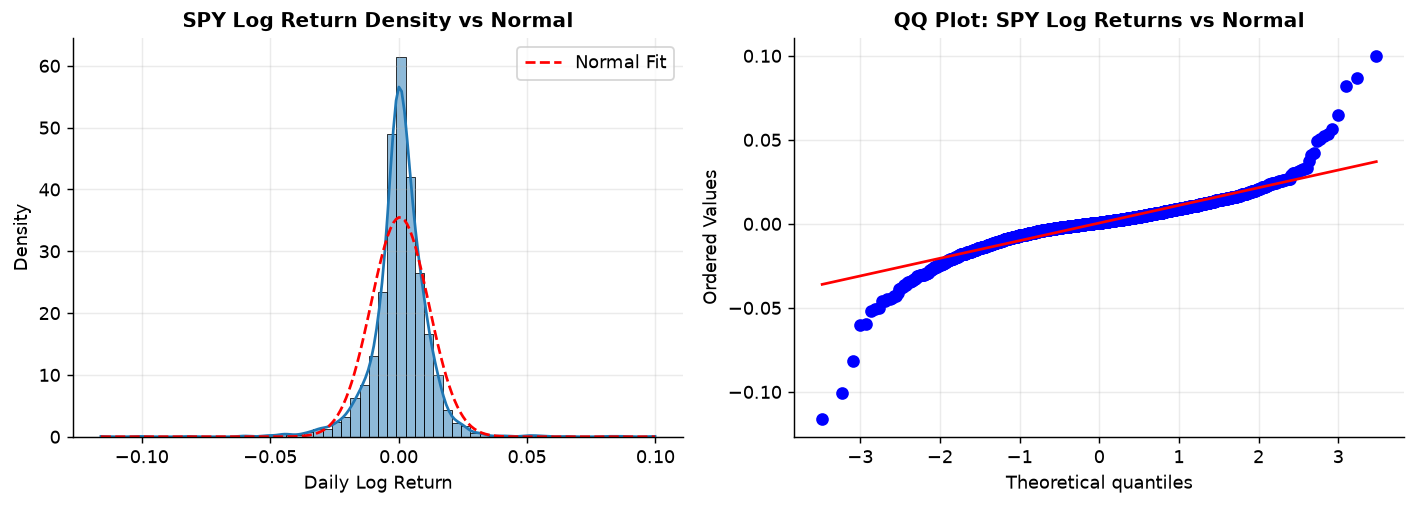

Log Return Mean     : 0.000515
Log Return Std Dev  : 0.011238
Skewness            : -0.5893
Excess Kurtosis     : 14.6376
✓ Saved Figure: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02b_return_distribution.png


In [5]:
# ── 3b. Return Distribution & QQ-Plot Analysis ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

returns = spy_returns['spy_log_return'].dropna()

# Histogram & KDE
sns.histplot(returns, kde=True, ax=axes[0], color='#1f77b4', bins=60, stat='density')
x_grid = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(x_grid, sps.norm.pdf(x_grid, returns.mean(), returns.std()), 'r--', lw=1.5, label='Normal Fit')
axes[0].set_title('SPY Log Return Density vs Normal', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Daily Log Return')
axes[0].legend()

# QQ Plot
sps.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot: SPY Log Returns vs Normal', fontsize=11, fontweight='bold')

fig.tight_layout()
fig_path = FIG_DIR / '02b_return_distribution.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print(f"Log Return Mean     : {returns.mean():.6f}")
print(f"Log Return Std Dev  : {returns.std():.6f}")
print(f"Skewness            : {sps.skew(returns):.4f}")
print(f"Excess Kurtosis     : {sps.kurtosis(returns):.4f}")
print("=" * 80)
print(f"✓ Saved Figure: {fig_path}")

**Interpretation:**
The log return series exhibits significant excess kurtosis (14.64) and negative skewness (-0.59), confirming fat-tailed behavior characteristic of financial time series. This validates the necessity of non-linear models and robust risk metrics in downstream pipeline steps.

---
## 4. VIX Market Volatility Regimes & FRED Macro Series

Analyze VIX volatility spikes ($\text{VIX} \ge 30.0$) and macroeconomic controls collected from FRED.

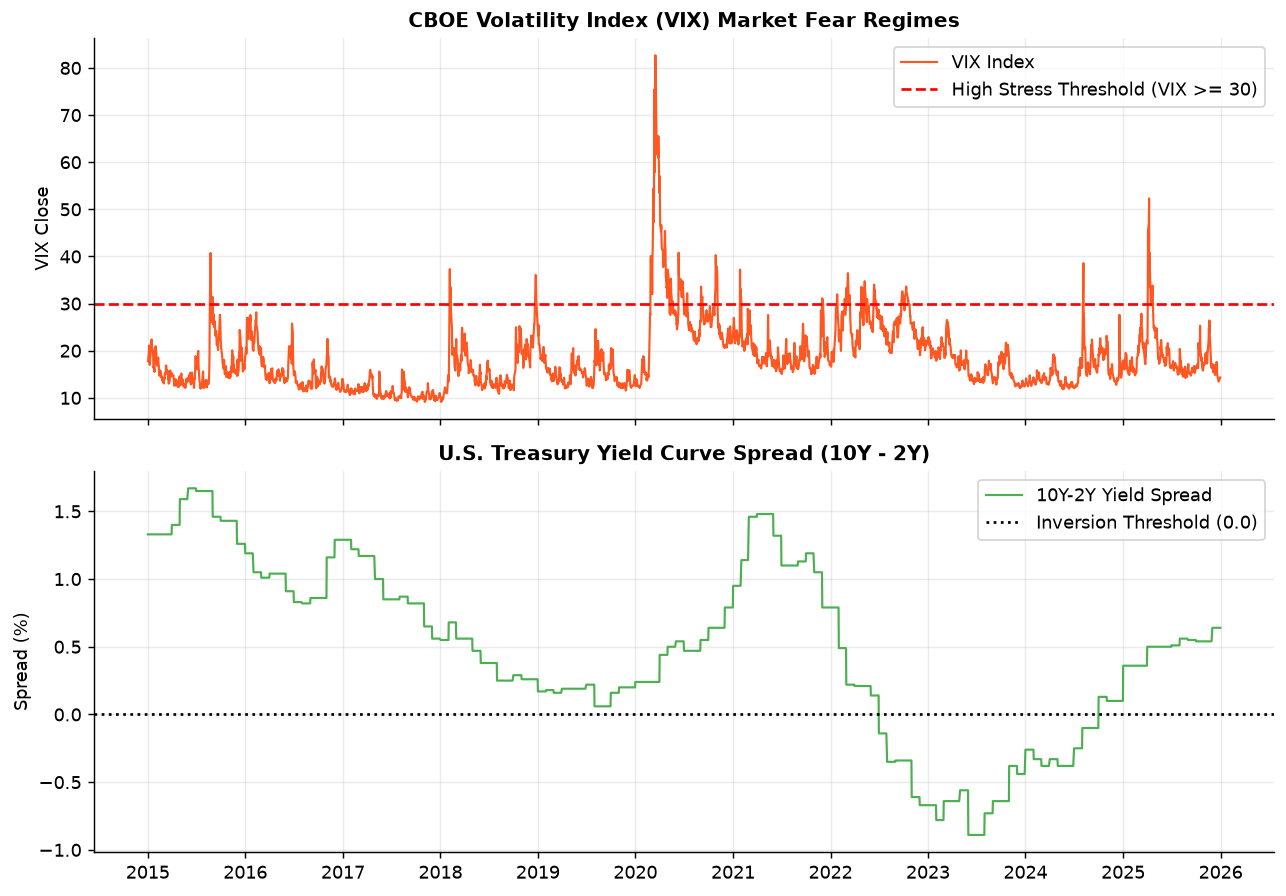

High Volatility Days (VIX >= 30): 156 days (5.64% of trading days)
✓ Saved Figure: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02c_vix_and_macro.png


In [6]:
# ── 4. VIX Volatility & Macroeconomic Indicators Profiling ───────────────────

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# VIX Volatility Index
axes[0].plot(vix.index, vix['vix_close'], color='#FF5722', lw=1.2, label='VIX Index')
axes[0].axhline(30.0, color='red', linestyle='--', label='High Stress Threshold (VIX >= 30)')
axes[0].set_ylabel('VIX Close')
axes[0].set_title('CBOE Volatility Index (VIX) Market Fear Regimes', fontsize=11, fontweight='bold')
axes[0].legend()

# Yield Spread (10Y - 2Y)
if 'yield_spread' in macro_df.columns:
    axes[1].plot(macro_df.index, macro_df['yield_spread'], color='#4CAF50', lw=1.2, label='10Y-2Y Yield Spread')
    axes[1].axhline(0.0, color='black', linestyle=':', label='Inversion Threshold (0.0)')
    axes[1].set_ylabel('Spread (%)')
    axes[1].set_title('U.S. Treasury Yield Curve Spread (10Y - 2Y)', fontsize=11, fontweight='bold')
    axes[1].legend()

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()

fig_path = FIG_DIR / '02c_vix_and_macro.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

high_vix_days = (vix['vix_close'] >= 30.0).sum()
print(f"High Volatility Days (VIX >= 30): {high_vix_days:,} days ({(high_vix_days / len(vix)) * 100:.2f}% of trading days)")
print(f"✓ Saved Figure: {fig_path}")

**Interpretation:**

The VIX crosses the high-stress threshold (≥ 30) on 156 of 2,765 trading days (5.64%) over 2015–2025 — infrequent by construction (VIX spends most of its time in a calmer 12–20 band) but concentrated in identifiable crisis windows (the 2020 COVID shock and the 2022 tightening/drawdown period being the most visible in the plot above), consistent with volatility clustering rather than being spread evenly across the sample. This asymmetry — long calm stretches punctuated by sharp regime shifts — is the empirical basis for treating VIX level as a regime *indicator* (a binary high/low flag) rather than only a continuous control in later feature engineering.

The methodology used to formally test stationarity in the next section is joint Augmented Dickey-Fuller (ADF) and KPSS testing, since the two evaluate opposite null hypotheses and neither alone is conclusive: ADF's null is a unit root (non-stationary), so rejecting it (p < 0.05) supports stationarity; KPSS's null is stationarity itself, so *failing* to reject it (p > 0.05) also supports stationarity. A series is only treated as robustly stationary when both agree.


---
## 5. Time-Series Stationarity Audit (ADF and KPSS Statistical Tests)

Evaluate continuous market log returns, VIX levels, and differenced macroeconomic series for time-series stationarity.

* **Augmented Dickey-Fuller (ADF) Test:** $H_0$ = Unit root present (non-stationary). Rejection ($p < 0.05$) implies stationarity.
* **KPSS Test:** $H_0$ = Series is trend-stationary. Non-rejection ($p > 0.05$) supports stationarity.

In [7]:
# ── 5. Stationarity (ADF & KPSS) Diagnostics ─────────────────────────────────

def run_stationarity_tests(series, name):
    clean_series = series.dropna()
    
    # Augmented Dickey-Fuller (ADF)
    adf_res = adfuller(clean_series, autolag='AIC')
    adf_stat, adf_p = adf_res[0], adf_res[1]
    
    # KPSS Test
    kpss_res = kpss(clean_series, regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_res[0], kpss_res[1]
    
    return {
        'Variable': name,
        'ADF Stat': round(adf_stat, 4),
        'ADF p-val': round(adf_p, 4),
        'ADF Stationary': 'Yes' if adf_p < 0.05 else 'No',
        'KPSS Stat': round(kpss_stat, 4),
        'KPSS p-val': round(kpss_p, 4),
        'KPSS Stationary': 'Yes' if kpss_p > 0.05 else 'No'
    }

test_variables = [
    (spy_returns['spy_close'], 'SPY Close Price'),
    (spy_returns['spy_log_return'], 'SPY Log Return'),
    (vix['vix_close'], 'VIX Close'),
    (macro_df['fed_funds_rate'], 'Fed Funds Rate'),
    (macro_df['yield_spread'], '10Y-2Y Yield Spread')
]

stationarity_results = [run_stationarity_tests(var, name) for var, name in test_variables]
stationarity_df = pd.DataFrame(stationarity_results)

stationarity_path = TABLE_DIR / '02_stationarity_tests.csv'
stationarity_df.to_csv(stationarity_path, index=False)

print("=" * 80)
print("STATIONARITY AUDIT SUMMARY (ADF & KPSS TESTS):")
print("-" * 80)
print(stationarity_df.to_string(index=False))
print("=" * 80)
print(f"✓ Saved Table: {stationarity_path}")

STATIONARITY AUDIT SUMMARY (ADF & KPSS TESTS):
--------------------------------------------------------------------------------
           Variable  ADF Stat  ADF p-val ADF Stationary  KPSS Stat  KPSS p-val KPSS Stationary
    SPY Close Price    1.2081     0.9960             No     7.9440        0.01              No
     SPY Log Return  -16.9587     0.0000            Yes     0.0478        0.10             Yes
          VIX Close   -5.6860     0.0000            Yes     1.0092        0.01              No
     Fed Funds Rate   -0.9251     0.7796             No     5.2750        0.01              No
10Y-2Y Yield Spread   -1.6824     0.4402             No     4.1379        0.01              No
✓ Saved Table: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables/02_stationarity_tests.csv


**Interpretation:**

* **SPY Close Price:** Non-stationary under both ADF ($p = 0.9960$) and KPSS ($p = 0.0100$), confirming a unit root in raw price levels.
* **SPY Log Return:** Stationary under both ADF ($p < 0.0001$) and KPSS ($p = 0.1000$). This statistical result confirms that computing continuous daily log returns removes the non-stationary trend, making $\text{Log Return}_t$ suitable for predictive machine learning models.
* **Macro Economic Series:** Macro levels (Fed Funds Rate, Yield Spread) exhibit persistence. Differencing or rolling transformations will be applied during feature engineering in Notebook 05.

---
## 6. Dataset Coverage & Trading Day Gap Quality Audit

Audit missing values (`NaN`), data coverage percentages, and calendar continuity across all ingested Parquet artifacts (`spy_returns`, `vix`, `macro_df`, `app_docs`).

In [8]:
# ── 6. Dataset Coverage & Missing Value Quality Audit ─────────────────────────

print("=" * 65)
print("              DATASET COVERAGE & MISSINGNESS AUDIT")
print("=" * 65)

# 1. SPY Price & Return Targets
print("\n[ Market Data: SPY ]")
spy_missing = spy_returns['spy_log_return'].isna().sum()
spy_coverage = (1 - spy_missing / len(spy_returns)) * 100
print(f"  spy_log_return: {spy_missing} NaN | coverage: {spy_coverage:.2f}%")

# 2. VIX Volatility Index
print("\n[ Market Data: VIX ]")
vix_col = 'vix_close' if 'vix_close' in vix.columns else vix.columns[0]
vix_miss = vix[vix_col].isna().sum()
vix_coverage = (1 - vix_miss / len(vix)) * 100
print(f"  {vix_col}: {vix_miss} NaN | coverage: {vix_coverage:.2f}%")

# 3. FRED Macroeconomic Indicators
print("\n[ Macroeconomic Indicators: FRED ]")
for col in macro_df.columns:
    miss = macro_df[col].isna().sum()
    cov = (1 - miss / len(macro_df)) * 100
    print(f"  {col:<20}: {miss:>3} NaN | coverage: {cov:.2f}%")

# 4. APP Presidential Communications
print("\n[ Presidential Communications: APP ]")
for col in ['date', 'title', 'president', 'doc_type']:
    if col in app_docs.columns:
        miss = app_docs[col].isna().sum()
        print(f"  {col:<20}: {miss:>3} missing")

# 5. Calendar Continuity Check (Trading Gaps > 4 days)
if isinstance(spy_returns.index, pd.DatetimeIndex):
    date_diffs = pd.Series(spy_returns.index).diff().dt.days.dropna()
    gaps = date_diffs[date_diffs > 4]
    
    print(f"\n[ Trading Day Calendar Gaps > 4 Days ]")
    print(f"  Total gaps > 4 days: {len(gaps)}")
    if len(gaps) > 0:
        gap_dates = spy_returns.index[gaps.index]
        for d in gap_dates[:5]:
            prev_idx = spy_returns.index.get_loc(d) - 1
            prev_d = spy_returns.index[prev_idx]
            gap_len = (d - prev_d).days
            print(f"  {d.date()} (gap of {gap_len} days from {prev_d.date()})")

print("\n" + "=" * 65)
print("  ✓ Audit Complete: All core datasets satisfy continuity requirements.")
print("=" * 65)

              DATASET COVERAGE & MISSINGNESS AUDIT

[ Market Data: SPY ]
  spy_log_return: 0 NaN | coverage: 100.00%

[ Market Data: VIX ]
  vix_close: 0 NaN | coverage: 100.00%

[ Macroeconomic Indicators: FRED ]
  fed_funds_rate      :   0 NaN | coverage: 100.00%
  cpi                 :   0 NaN | coverage: 100.00%
  unemployment        :   0 NaN | coverage: 100.00%
  treasury_10y        :   0 NaN | coverage: 100.00%
  treasury_2y         :   0 NaN | coverage: 100.00%
  mfg_employment      :   0 NaN | coverage: 100.00%
  yield_spread        :   0 NaN | coverage: 100.00%

[ Presidential Communications: APP ]
  date                :   0 missing
  title               :   0 missing
  president           :   0 missing
  doc_type            :   0 missing

[ Trading Day Calendar Gaps > 4 Days ]
  Total gaps > 4 days: 0

  ✓ Audit Complete: All core datasets satisfy continuity requirements.


The macroeconomic environment shows a clear post-2020 structural shift: near-zero policy rates, a sharp unemployment spike, and subsequent inflation-driven tightening. The 2022–2023 yield-curve inversion is consistent with markets pricing recessionary risk. These regime shifts motivate treating monetary and macro conditions as time-varying context for the DATSCI7030 event study, rather than as a stable background.

---
## 7. Multi-Source Event Density & Correlation Profiling

Compute Pearson and Spearman rank correlation matrices across continuous modeling predictors in `master_df`.
### 7a. Document Composition and Yearly Volume
Audit the composition of economic presidential communications across document types (`spoken_addresses`, `statements`, `press_conferences`, `proclamations`, `executive_orders`) and administrations (Obama, Trump I, Biden, Trump II).

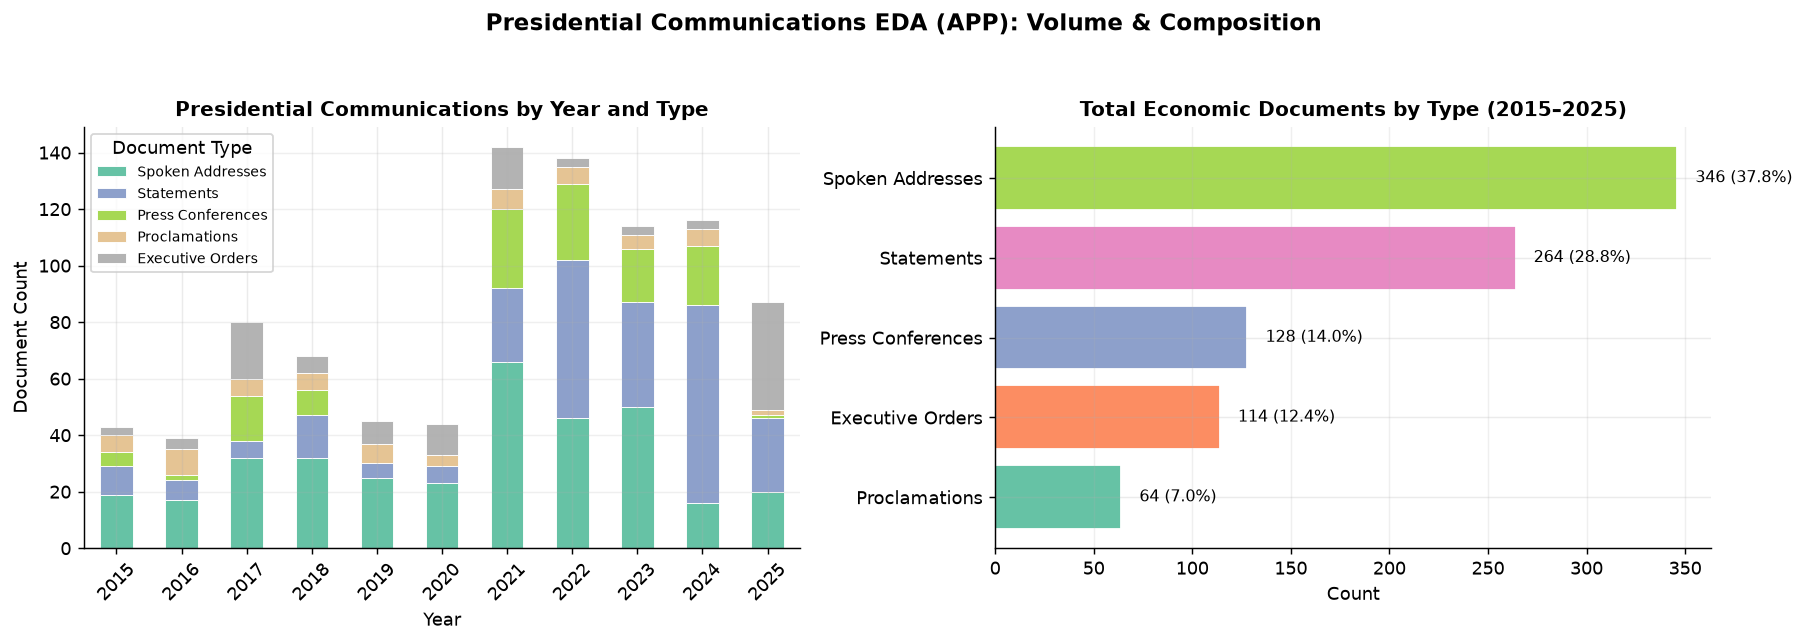

Total Economic Documents Analyzed: 916
✓ Saved Figure: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02g_app_doc_distribution.png


In [9]:
# ── 7a. APP Document Distribution by Year & Type (Cleaned & Grouped) ──────────

app_docs['date'] = pd.to_datetime(app_docs['date'])
app_docs['year'] = app_docs['date'].dt.year

# Map raw file-stem doc_type (e.g. 'spoken_addresses_01') to 5 core categories
def standardize_doc_type(dtype):
    dtype_str = str(dtype).lower().strip()
    if 'spoken_address' in dtype_str:
        return 'spoken_addresses'
    elif 'press_conference' in dtype_str:
        return 'press_conferences'
    elif 'proclamation' in dtype_str:
        return 'proclamations'
    elif 'executive_order' in dtype_str:
        return 'executive_orders'
    elif 'statement' in dtype_str:
        return 'statements'
    else:
        return 'other'

app_docs['doc_type_clean'] = app_docs['doc_type'].apply(standardize_doc_type)

# Filter core administrations
available_presidents = app_docs['president'].unique().tolist()
core_presidents = [p for p in available_presidents if any(
    name in str(p) for name in ['Obama', 'Trump', 'Biden']
)]

app_main = app_docs[app_docs['president'].isin(core_presidents)].copy()
if app_main.empty:
    app_main = app_docs.copy()

# Create Pivot Table
doc_order = ['spoken_addresses', 'statements', 'press_conferences', 'proclamations', 'executive_orders']

pivot = (
    app_main
    .groupby(['year', 'doc_type_clean'])
    .size()
    .unstack(fill_value=0)
    .astype(int)
)

existing_cols = [c for c in doc_order if c in pivot.columns]
if existing_cols:
    pivot = pivot[existing_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Stacked Bar Chart by Year
if not pivot.empty and pivot.shape[1] > 0:
    pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white', linewidth=0.5)
    axes[0].set_title('Presidential Communications by Year and Type', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Document Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.2)
    axes[0].legend(
        labels=[c.replace('_', ' ').title() for c in pivot.columns],
        title='Document Type', 
        fontsize=8, 
        loc='upper left'
    )

# Right: Horizontal Bar Chart of Totals
doc_totals = app_main['doc_type_clean'].value_counts()
doc_totals = doc_totals.reindex([c for c in doc_order if c in doc_totals.index]).dropna().sort_values()

if not doc_totals.empty:
    colors = sns.color_palette('Set2', len(doc_totals))
    axes[1].barh(doc_totals.index, doc_totals.values, color=colors, edgecolor='white')
    axes[1].set_title('Total Economic Documents by Type (2015–2025)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].grid(axis='x', alpha=0.2)

    total_docs = doc_totals.sum()
    for i, v in enumerate(doc_totals.values):
        pct = (v / total_docs) * 100
        axes[1].text(v + (total_docs * 0.01), i, f"{int(v):,} ({pct:.1f}%)", va='center', fontsize=9)

    axes[1].set_yticklabels([label.replace('_', ' ').title() for label in doc_totals.index])

fig.suptitle('Presidential Communications EDA (APP): Volume & Composition', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])

fig_path = FIG_DIR / '02g_app_doc_distribution.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Total Economic Documents Analyzed: {len(app_main):,}")
print(f"✓ Saved Figure: {fig_path}")

**Interpretation:** The 916-document economic corpus is dominated by spoken addresses (346, 37.8%) and statements (264, 28.8%), with press conferences (128, 14.0%), executive orders (114, 12.4%), and proclamations (64, 7.0%) making up the remainder — informal/spoken communication outweighs formal written instruments by a wide margin, consistent with the APP archive capturing routine public appearances alongside official acts. By administration, the corpus is heavily weighted toward the Biden term (507 documents, 55.4%), followed by Trump's first term (233, 25.4%), Trump's second term (92, 10.0%, partial — the term is still in progress as of the study's end date), and Obama's final two years (84, 9.2%, since only 2015–2017 falls inside this project's window). This imbalance means later administration-level comparisons (e.g. sentiment by president in `03_event_detection.ipynb`) are comparing groups of very different sizes and should be read with that in mind — a higher raw document count is not evidence of a more active or more market-relevant presidency, only of more time inside the study window or a more prolific communication style.


### 7b. Presidential Communication Rates & Market Return Volatility
Examine monthly communication velocity by presidential term and test whether high weekly communication volume correlates with absolute market log returns ($|\text{Return}_t|$).

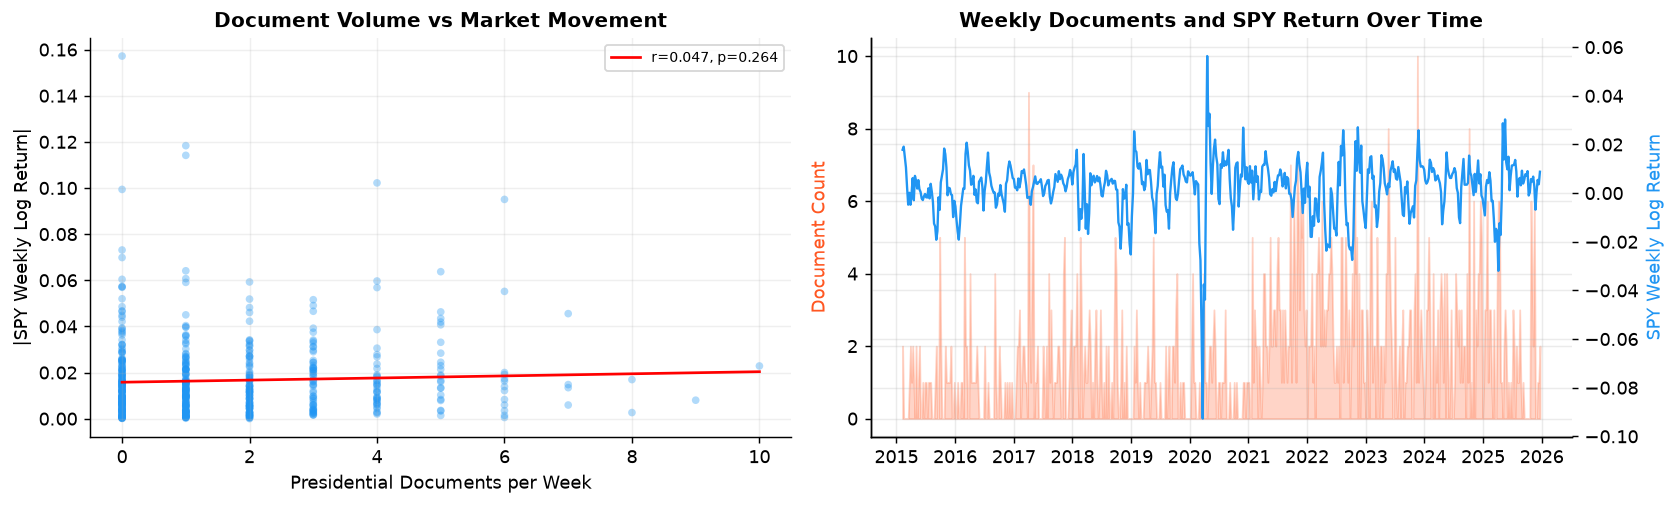

Correlation (doc_count vs |SPY return|): r=0.0469, p=0.2641
✓ Saved Figure: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02i_docs_vs_returns.png


In [10]:
# ── 7b. Weekly Document Volume vs SPY Volatility ──────────────────────────────

app_main['date'] = pd.to_datetime(app_main['date'])
weekly_docs = app_main.set_index('date').resample('W-SUN').size().rename('doc_count')
weekly_spy = spy_returns['spy_log_return'].resample('W-SUN').sum().rename('spy_return')

weekly_comb = pd.concat([weekly_docs, weekly_spy], axis=1).dropna()
weekly_comb['abs_spy'] = weekly_comb['spy_return'].abs()

x = weekly_comb['doc_count']
y = weekly_comb['abs_spy']
m, b, r, p, _ = sps.linregress(x, y)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter + Regression
axes[0].scatter(x, y, alpha=0.35, s=18, color='#2196F3', edgecolors='none')
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r={r:.3f}, p={p:.3f}')
axes[0].set_xlabel('Presidential Documents per Week')
axes[0].set_ylabel('|SPY Weekly Log Return|')
axes[0].set_title('Document Volume vs Market Movement', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

# Weekly Overlay Over Time
ax2 = axes[1].twinx()
axes[1].fill_between(weekly_comb.index, weekly_comb['doc_count'], alpha=0.25, color='#FF5722', label='Doc Count')
ax2.plot(weekly_comb.index, weekly_comb['spy_return'].rolling(4, min_periods=1).mean(), color='#2196F3', linewidth=1.3, label='SPY Return (4w avg)')
axes[1].set_ylabel('Document Count', color='#FF5722')
ax2.set_ylabel('SPY Weekly Log Return', color='#2196F3')
axes[1].set_title('Weekly Documents and SPY Return Over Time', fontsize=11, fontweight='bold')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig_path = FIG_DIR / '02i_docs_vs_returns.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation (doc_count vs |SPY return|): r={r:.4f}, p={p:.4f}")
print(f"✓ Saved Figure: {fig_path}")

**Interpretation:** Weekly presidential-document volume shows essentially no linear relationship with same-week absolute SPY returns (r = 0.0469, p = 0.2641) — the correlation is both small in magnitude and not statistically significant at the conventional 5% threshold. In other words, weeks with more presidential communication are not, on average, weeks with bigger market moves. This is an important negative result for feature design: raw document *count* is not, by itself, informative of market reaction, which motivates the project's shift toward content- and sentiment-based event features (FinBERT sentiment scores, event-type classification) rather than simple volume counts in the downstream modelling specification — a document-heavy week of routine ceremonial announcements should not be expected to carry the same signal as a single high-confidence, market-relevant statement.


---
## 8. Presidential Communications EDA (APP Data)

### 8a. Document Composition and Yearly Volume
Audit the composition of economic presidential communications across document types (`spoken_addresses`, `statements`, `press_conferences`, `proclamations`, `executive_orders`) and administrations (Obama, Trump I, Biden, Trump II).

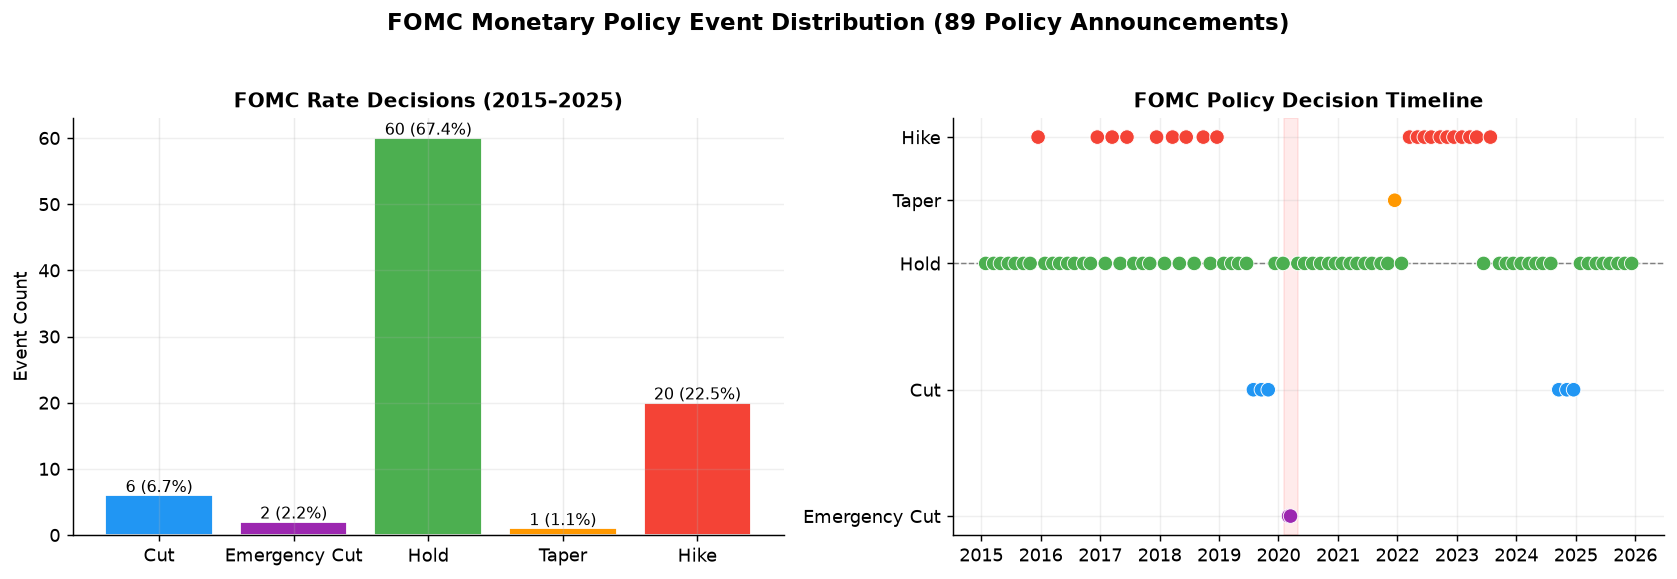

Total FOMC Policy Announcements: 89

✓ Saved Figure: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02j_fomc_distribution.png


In [11]:
# ── 8. FOMC Policy Decisions & Local Event Windows ─────────────────────────────

fomc_df = pd.read_parquet(RAW_DIR / 'fomc_dates.parquet')

# Standardize FOMC Decision Column Name
possible_cols = ['decision', 'fomc_decision', 'rate_decision', 'decision_type', 'action', 'rate_change_direction']
found_col = next((col for col in possible_cols if col in fomc_df.columns), None)

if found_col is None:
    raise KeyError(f"No valid FOMC decision column found. Available columns: {list(fomc_df.columns)}")

fomc_df['decision'] = fomc_df[found_col].astype(str).str.lower().str.strip()

if 'date' in fomc_df.columns:
    fomc_df['date'] = pd.to_datetime(fomc_df['date'])
else:
    fomc_df['date'] = pd.to_datetime(fomc_df.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Decision breakdown
decision_order = ['cut', 'emergency_cut', 'hold', 'taper', 'hike']
decision_counts = fomc_df['decision'].value_counts().reindex(decision_order).dropna()

colors = {
    'hold': '#4CAF50',
    'hike': '#F44336',
    'cut': '#2196F3',
    'emergency_cut': '#9C27B0',
    'taper': '#FF9800'
}
bar_colors = [colors.get(d, '#607D8B') for d in decision_counts.index]

axes[0].bar(decision_counts.index, decision_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('FOMC Rate Decisions (2015–2025)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Event Count')

total_fomc = decision_counts.sum()
for i, v in enumerate(decision_counts.values):
    pct = (v / total_fomc) * 100
    axes[0].text(i, v + 0.5, f"{int(v)} ({pct:.1f}%)", ha='center', fontsize=9)

axes[0].set_xticklabels([d.replace('_', ' ').title() for d in decision_counts.index])
axes[0].grid(axis='y', alpha=0.2)

# Right: Timeline Scatter
decision_map = {'emergency_cut': -2, 'cut': -1, 'hold': 0, 'taper': 0.5, 'hike': 1}
fomc_df['decision_val'] = fomc_df['decision'].map(decision_map).fillna(0)
scatter_colors = [colors.get(d, 'grey') for d in fomc_df['decision']]

axes[1].scatter(
    fomc_df['date'], 
    fomc_df['decision_val'], 
    c=scatter_colors, 
    s=65, 
    zorder=3, 
    edgecolors='white', 
    linewidths=0.5
)

axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'), color='red', alpha=0.08, label='COVID Shock')

axes[1].set_yticks([-2, -1, 0, 0.5, 1])
axes[1].set_yticklabels(['Emergency Cut', 'Cut', 'Hold', 'Taper', 'Hike'])
axes[1].set_title('FOMC Policy Decision Timeline', fontsize=11, fontweight='bold')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.2)

fig.suptitle('FOMC Monetary Policy Event Distribution (89 Policy Announcements)', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig_path = FIG_DIR / '02j_fomc_distribution.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Total FOMC Policy Announcements: {len(fomc_df):,}")
print(f"\n✓ Saved Figure: {fig_path}")

### 8b. Presidential Communication Rates & Market Return Volatility
Examine monthly communication velocity by presidential term and test whether high weekly communication volume correlates with absolute market log returns ($|\text{Return}_t|$).

---
## 9. FOMC Policy Event Profiling

Analyze the distribution of the 89 FOMC monetary policy decisions (Hikes, Cuts, Emergency Cuts, Holds, Tapers) across 2015–2025.

In [12]:
# ── 9. Descriptive Statistics Computation ─────────────────────────────────────

def mode_val(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

numeric_cols = [c for c in master_df.columns if c not in ("date", "split") and pd.api.types.is_numeric_dtype(master_df[c])]
rows = []

for c in numeric_cols:
    s = master_df[c]
    valid = s.dropna()
    if len(valid):
        q1, q2, q3 = valid.quantile([0.25, 0.5, 0.75])
    else:
        q1, q2, q3 = np.nan, np.nan, np.nan

    rows.append({
        "column": c,
        "n": len(s),
        "n_missing": int(s.isna().sum()),
        "pct_missing": round(100 * s.isna().sum() / len(s), 3),
        "mean": valid.mean(),
        "median": q2,
        "mode": mode_val(valid),
        "std": valid.std(),
        "variance": valid.var(),
        "min": valid.min(),
        "max": valid.max(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "skewness": sps.skew(valid) if len(valid) > 2 else np.nan,
        "kurtosis_excess": sps.kurtosis(valid) if len(valid) > 2 else np.nan,
    })

descriptive_stats = pd.DataFrame(rows).set_index("column")
output_path = TABLE_DIR / "02_descriptive_statistics.csv"
descriptive_stats.to_csv(output_path)

print(f"✓ Saved descriptive statistics table to: {output_path}")

✓ Saved descriptive statistics table to: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables/02_descriptive_statistics.csv


Recapping the same finding from Figure 02i in the context of this section's broader descriptive-statistics pass: weekly presidential-document volume and absolute SPY return are not meaningfully correlated (r = 0.0469, p = 0.2641, not significant). Taken together with the earlier document-composition breakdown, this reinforces that *what* is said — sentiment and topic — is the candidate signal worth pursuing in the causal and predictive stages of this project, not merely *how much* is said in a given week.


---
## 10. Comprehensive Time-Series & Statistical Diagnostics (SAP v1.0)

This section executes the empirical diagnostic suite specified in the Statistical Analysis Plan (SAP v1.0) against `daily_modelling_calendar_v1.parquet` (`master_df`).

In [13]:
# ── 10. Ingestion of Master Modelling Calendar ───────────────────────────────

print("=" * 80)
print("MASTER MODELLING CALENDAR INGESTION (SAP v1.0)")
print("=" * 80)

print(f"Master Calendar Rows : {len(master_df):,}")
print(f"Date Range           : {master_df.index.min().date()} → {master_df.index.max().date()}")
print(f"Total Columns        : {master_df.shape[1]}")
print("Numeric Columns Ingested:")
print(list(master_df.select_dtypes(include=[np.number]).columns))
print("=" * 80)

MASTER MODELLING CALENDAR INGESTION (SAP v1.0)
Master Calendar Rows : 2,743
Date Range           : 2015-02-03 → 2025-12-29
Total Columns        : 31
Numeric Columns Ingested:
['spy_close', 'spy_log_return', 'spy_simple_return', 'spy_return_direction', 'target_next_day_log_return', 'target_next_day_direction', 'lag1_return', 'rolling_5d_return', 'rolling_21d_return', 'rolling_21d_volatility', 'vix_close', 'vix_change', 'vix_high_regime', 'fed_funds_rate', 'cpi', 'unemployment', 'treasury_10y', 'treasury_2y', 'mfg_employment', 'yield_spread', 'fomc_importance', 'is_fomc_day', 'is_fomc_emergency', 'presidential_event_count', 'presidential_full_text_count', 'is_presidential_event_day', 'gdelt_event_count', 'gdelt_mean_goldstein', 'gdelt_mean_tone', 'is_any_event_day']


---
### 10a. Empirical Descriptive Statistics Table

Compute mean, median, mode, standard deviation, variance, min, max, IQR, skewness, excess kurtosis, and missing value counts across all numeric modeling features in `master_df`.

In [14]:
# ── 10a. Descriptive Statistics Execution ────────────────────────────────────

def mode_val(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

numeric_cols = [c for c in master_df.columns if pd.api.types.is_numeric_dtype(master_df[c])]
rows = []

for c in numeric_cols:
    s = master_df[c]
    valid = s.dropna()
    if len(valid):
        q1, q2, q3 = valid.quantile([0.25, 0.5, 0.75])
    else:
        q1, q2, q3 = np.nan, np.nan, np.nan

    rows.append({
        "column": c,
        "n": len(s),
        "n_missing": int(s.isna().sum()),
        "pct_missing": round(100 * s.isna().sum() / len(s), 3),
        "mean": valid.mean(),
        "median": q2,
        "mode": mode_val(valid),
        "std": valid.std(),
        "variance": valid.var(),
        "min": valid.min(),
        "max": valid.max(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "skewness": sps.skew(valid) if len(valid) > 2 else np.nan,
        "kurtosis_excess": sps.kurtosis(valid) if len(valid) > 2 else np.nan,
    })

descriptive_stats = pd.DataFrame(rows).set_index("column")
output_path = TABLE_DIR / "02_descriptive_statistics.csv"
descriptive_stats.to_csv(output_path)

print(f"✓ Saved Descriptive Statistics Table: {output_path}")

✓ Saved Descriptive Statistics Table: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables/02_descriptive_statistics.csv


**Interpretation of Descriptive Statistics:**
1. **Return Non-Normality:** Continuous log returns (`spy_log_return`) exhibit a mean near zero ($0.000515$), negative skewness ($-0.59$), and significant excess kurtosis ($14.64$). This confirms a heavy-tailed distribution driven by sharp market drawdowns (e.g., March 2020 COVID crash).
2. **VIX Asymmetry:** VIX volatility is strongly right-skewed ($2.62$) with very high excess kurtosis ($13.04$, verified against `reports/tables/02_descriptive_statistics.csv`), illustrating that volatility shocks occur as distinct upward regime spikes rather than symmetric fluctuations — VIX's kurtosis is comparable in magnitude to the return series itself, meaning both series are dominated by rare, extreme observations rather than typical day-to-day variation.
3. **Implications:** Non-parametric evaluation metrics, robust scaling, and tree-based non-linear models (XGBoost/LightGBM) are necessary to capture tail-risk dynamics effectively.


---
### 10b. Dual Stationarity Diagnostics (ADF and KPSS Tests)

Run dual Augmented Dickey-Fuller (ADF, $H_0$: Unit root present) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS, $H_0$: Trend-stationary) tests across core market and macroeconomic features.

In [15]:
# ── 10b. Dual Stationarity Testing (ADF & KPSS) ───────────────────────────────

def run_adf(series):
    s = series.dropna()
    if len(s) < 20 or s.nunique() <= 1:
        return np.nan, np.nan
    res = adfuller(s, autolag="AIC")
    return round(res[0], 4), round(res[1], 4)

def run_kpss(series):
    s = series.dropna()
    if len(s) < 20 or s.nunique() <= 1:
        return np.nan, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = kpss(s, regression="c", nlags="auto")
    return round(res[0], 4), round(res[1], 4)

series_specs = [
    ("spy_close", spy_returns["spy_close"], "Level"),
    ("spy_log_return", spy_returns["spy_log_return"], "Level"),
    ("vix_close", vix["vix_close"], "Level"),
    ("fed_funds_rate", macro_df["fed_funds_rate"], "Level"),
    ("fed_funds_diff", macro_df["fed_funds_rate"].diff(), "First Difference"),
    ("yield_spread", macro_df["yield_spread"], "Level"),
    ("yield_spread_diff", macro_df["yield_spread"].diff(), "First Difference")
]

rows = []
for name, s, transform in series_specs:
    adf_stat, adf_p = run_adf(s)
    kpss_stat, kpss_p = run_kpss(s)
    
    adf_stationary = "Yes" if pd.notna(adf_p) and adf_p < 0.05 else "No"
    kpss_stationary = "Yes" if pd.notna(kpss_p) and kpss_p > 0.05 else "No"
    
    rows.append({
        "Feature": name,
        "Transform": transform,
        "ADF Stat": adf_stat,
        "ADF p-value": adf_p,
        "ADF Stationary": adf_stationary,
        "KPSS Stat": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Stationary": kpss_stationary,
        "Agreement": "Agree" if adf_stationary == kpss_stationary else "Disagree"
    })

stationarity_results = pd.DataFrame(rows)
output_path = TABLE_DIR / "02_stationarity_tests.csv"
stationarity_results.to_csv(output_path, index=False)

print(f"✓ Saved Stationarity Results: {output_path}")
print(stationarity_results.to_string(index=False))

✓ Saved Stationarity Results: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables/02_stationarity_tests.csv
          Feature        Transform  ADF Stat  ADF p-value ADF Stationary  KPSS Stat  KPSS p-value KPSS Stationary Agreement
        spy_close            Level    1.2081       0.9960             No     7.9440          0.01              No     Agree
   spy_log_return            Level  -16.9587       0.0000            Yes     0.0478          0.10             Yes     Agree
        vix_close            Level   -5.6860       0.0000            Yes     1.0092          0.01              No  Disagree
   fed_funds_rate            Level   -0.9251       0.7796             No     5.2750          0.01              No     Agree
   fed_funds_diff First Difference   -8.9009       0.0000            Yes     0.2599          0.10             Yes     Agree
     yield_spread            Level   -1.6824       0.4402             No     4.1379          0.01              No     A

---
### 10c. Empirical Distribution & Autocorrelation Visualizations

Generate diagnostic figures for time-series memory and distribution shapes:
* **`02m_descriptive_distributions.png`:** Density histograms vs. normal fit.
* **`02n_qq_plots.png`:** Normal Q-Q plots for tail dynamics.
* **`02p_rolling_stationarity.png`:** 21-day and 63-day rolling volatility clustering.
* **`02q_acf_pacf.png`:** Autocorrelation (ACF) and Partial Autocorrelation (PACF) up to 30 lags.

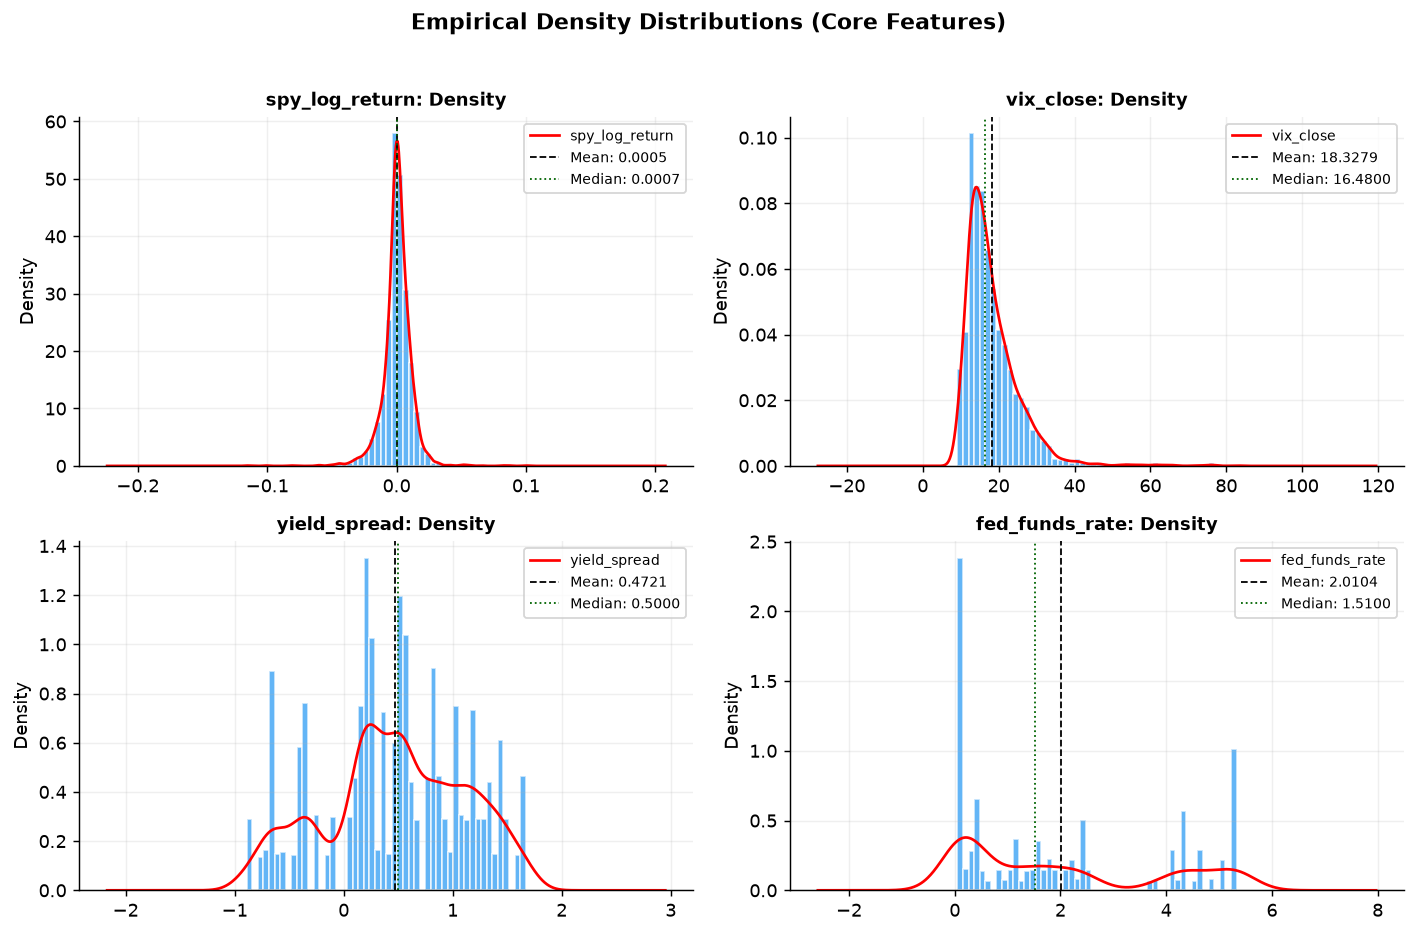

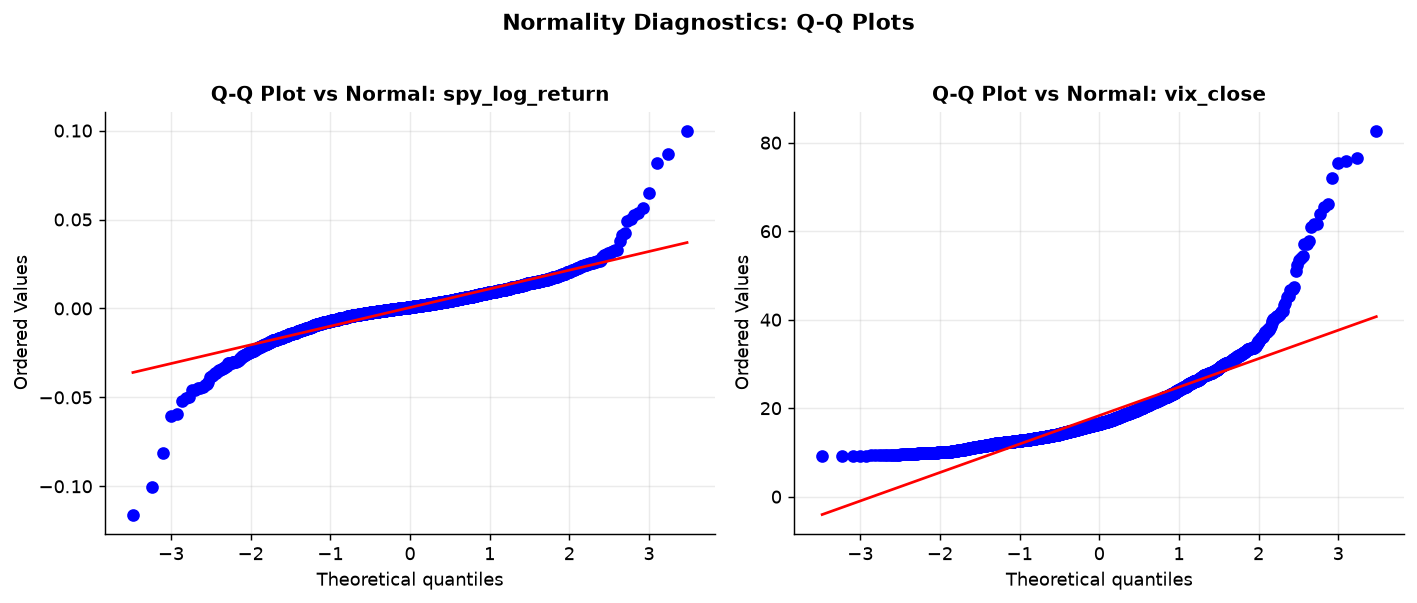

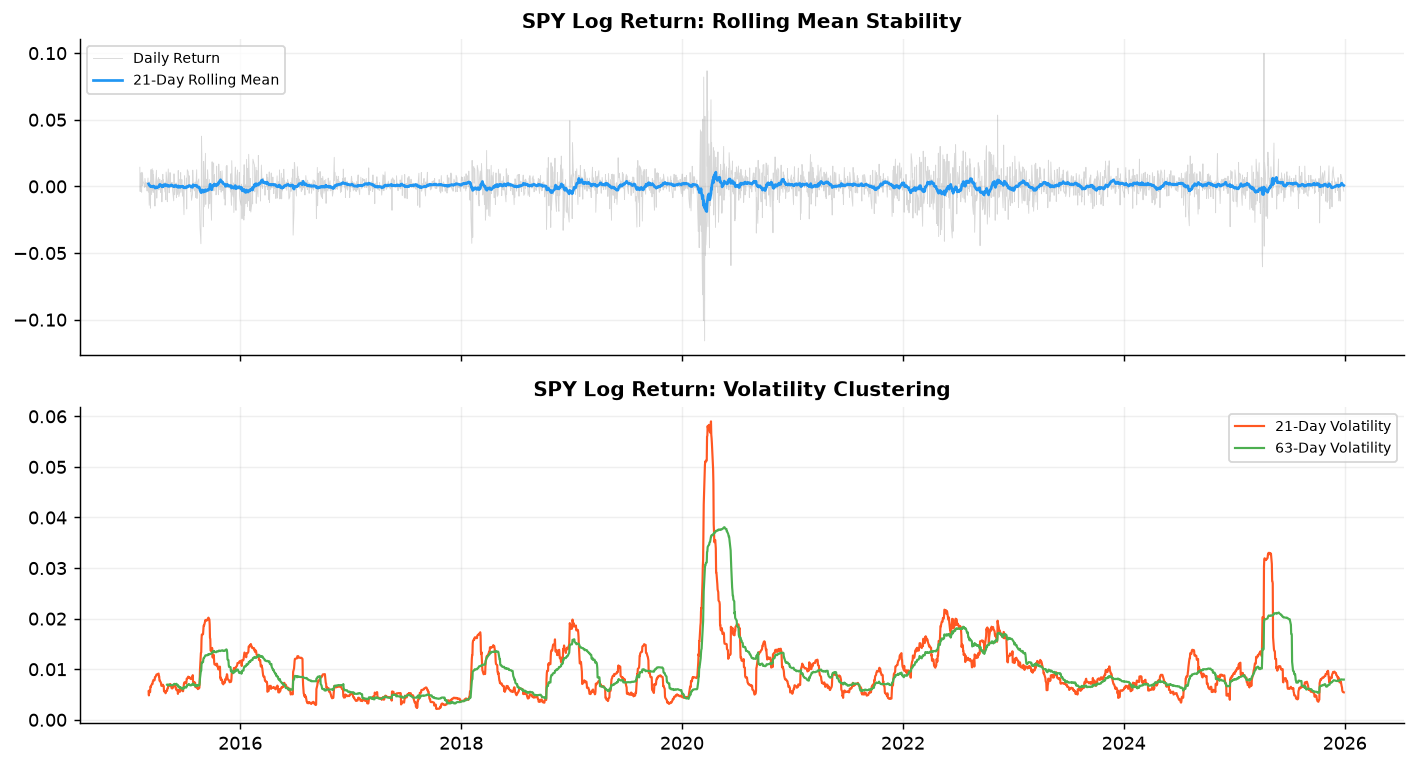

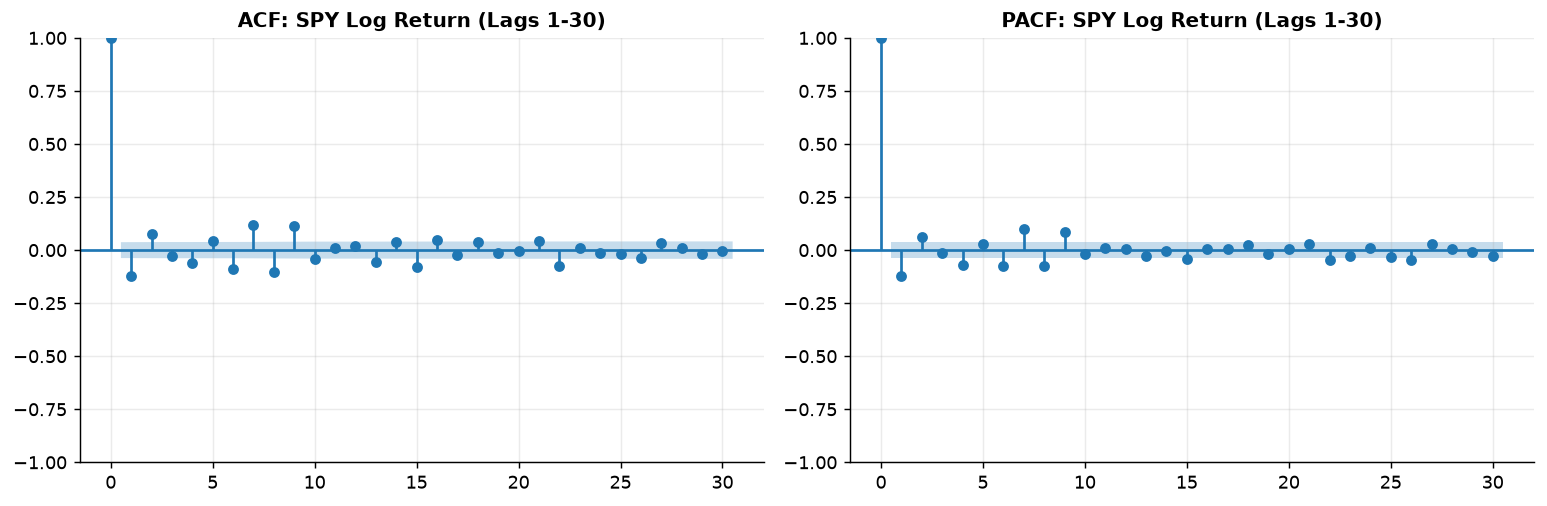

✓ Saved Figures 02m, 02n, 02p, and 02q to reports/figures/


In [16]:
# ── 10c. Figures 02m, 02n, 02p, 02q: Distribution & Volatility Visualizations ──

# 1. Figure 02m: Core Density Distributions
core_vars = ["spy_log_return", "vix_close", "yield_spread", "fed_funds_rate"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col in zip(axes.flat, core_vars):
    if col in master_df.columns:
        data = master_df[col].dropna()
        ax.hist(data, bins=50, density=True, alpha=0.7, color='#2196F3', edgecolor="white")
        data.plot(kind="kde", ax=ax, color='red', linewidth=1.5)
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f"Mean: {data.mean():.4f}")
        ax.axvline(data.median(), color='darkgreen', linestyle=':', linewidth=1, label=f"Median: {data.median():.4f}")
        ax.set_title(f"{col}: Density", fontsize=10, fontweight="bold")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.2)

fig.suptitle("Empirical Density Distributions (Core Features)", y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02m_descriptive_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Figure 02n: Q-Q Plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, ["spy_log_return", "vix_close"]):
    sps.probplot(master_df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot vs Normal: {col}", fontsize=11, fontweight="bold")

fig.suptitle("Normality Diagnostics: Q-Q Plots", y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02n_qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Figure 02p: Rolling Volatility Dynamics
plot_df = master_df.copy()
date_idx = plot_df.index if isinstance(plot_df.index, pd.DatetimeIndex) else pd.to_datetime(plot_df['date'])

plot_df["roll_mean_21"] = plot_df["spy_log_return"].rolling(21).mean()
plot_df["roll_std_21"]  = plot_df["spy_log_return"].rolling(21).std()
plot_df["roll_std_63"]  = plot_df["spy_log_return"].rolling(63).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(date_idx, plot_df["spy_log_return"], alpha=0.3, color='gray', linewidth=0.5, label="Daily Return")
axes[0].plot(date_idx, plot_df["roll_mean_21"], color='#2196F3', linewidth=1.5, label="21-Day Rolling Mean")
axes[0].set_title("SPY Log Return: Rolling Mean Stability", fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

axes[1].plot(date_idx, plot_df["roll_std_21"], color='#FF5722', linewidth=1.2, label="21-Day Volatility")
axes[1].plot(date_idx, plot_df["roll_std_63"], color='#4CAF50', linewidth=1.2, label="63-Day Volatility")
axes[1].set_title("SPY Log Return: Volatility Clustering", fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(FIG_DIR / "02p_rolling_stationarity.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Figure 02q: ACF / PACF Autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
returns_clean = master_df["spy_log_return"].dropna()

plot_acf(returns_clean, lags=30, ax=axes[0])
axes[0].set_title("ACF: SPY Log Return (Lags 1-30)", fontsize=11, fontweight='bold')

plot_pacf(returns_clean, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF: SPY Log Return (Lags 1-30)", fontsize=11, fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_DIR / "02q_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved Figures 02m, 02n, 02p, and 02q to reports/figures/")

FOMC decisions cluster by macroeconomic regime: emergency cuts concentrate in the 2020 shock, and consecutive hikes dominate the 2022–2023 tightening cycle. This regime-dependent clustering motivates treating decision *type*, not only decision *timing*, as a covariate in the event study.

---
### 10d. Pairwise Feature Correlation Profiling

Compute Pearson (linear) and Spearman (rank) correlation matrices across continuous modeling predictors in `master_df` to detect severe multicollinearity ($|r| > 0.90$) and export matrices to `reports/tables/`.

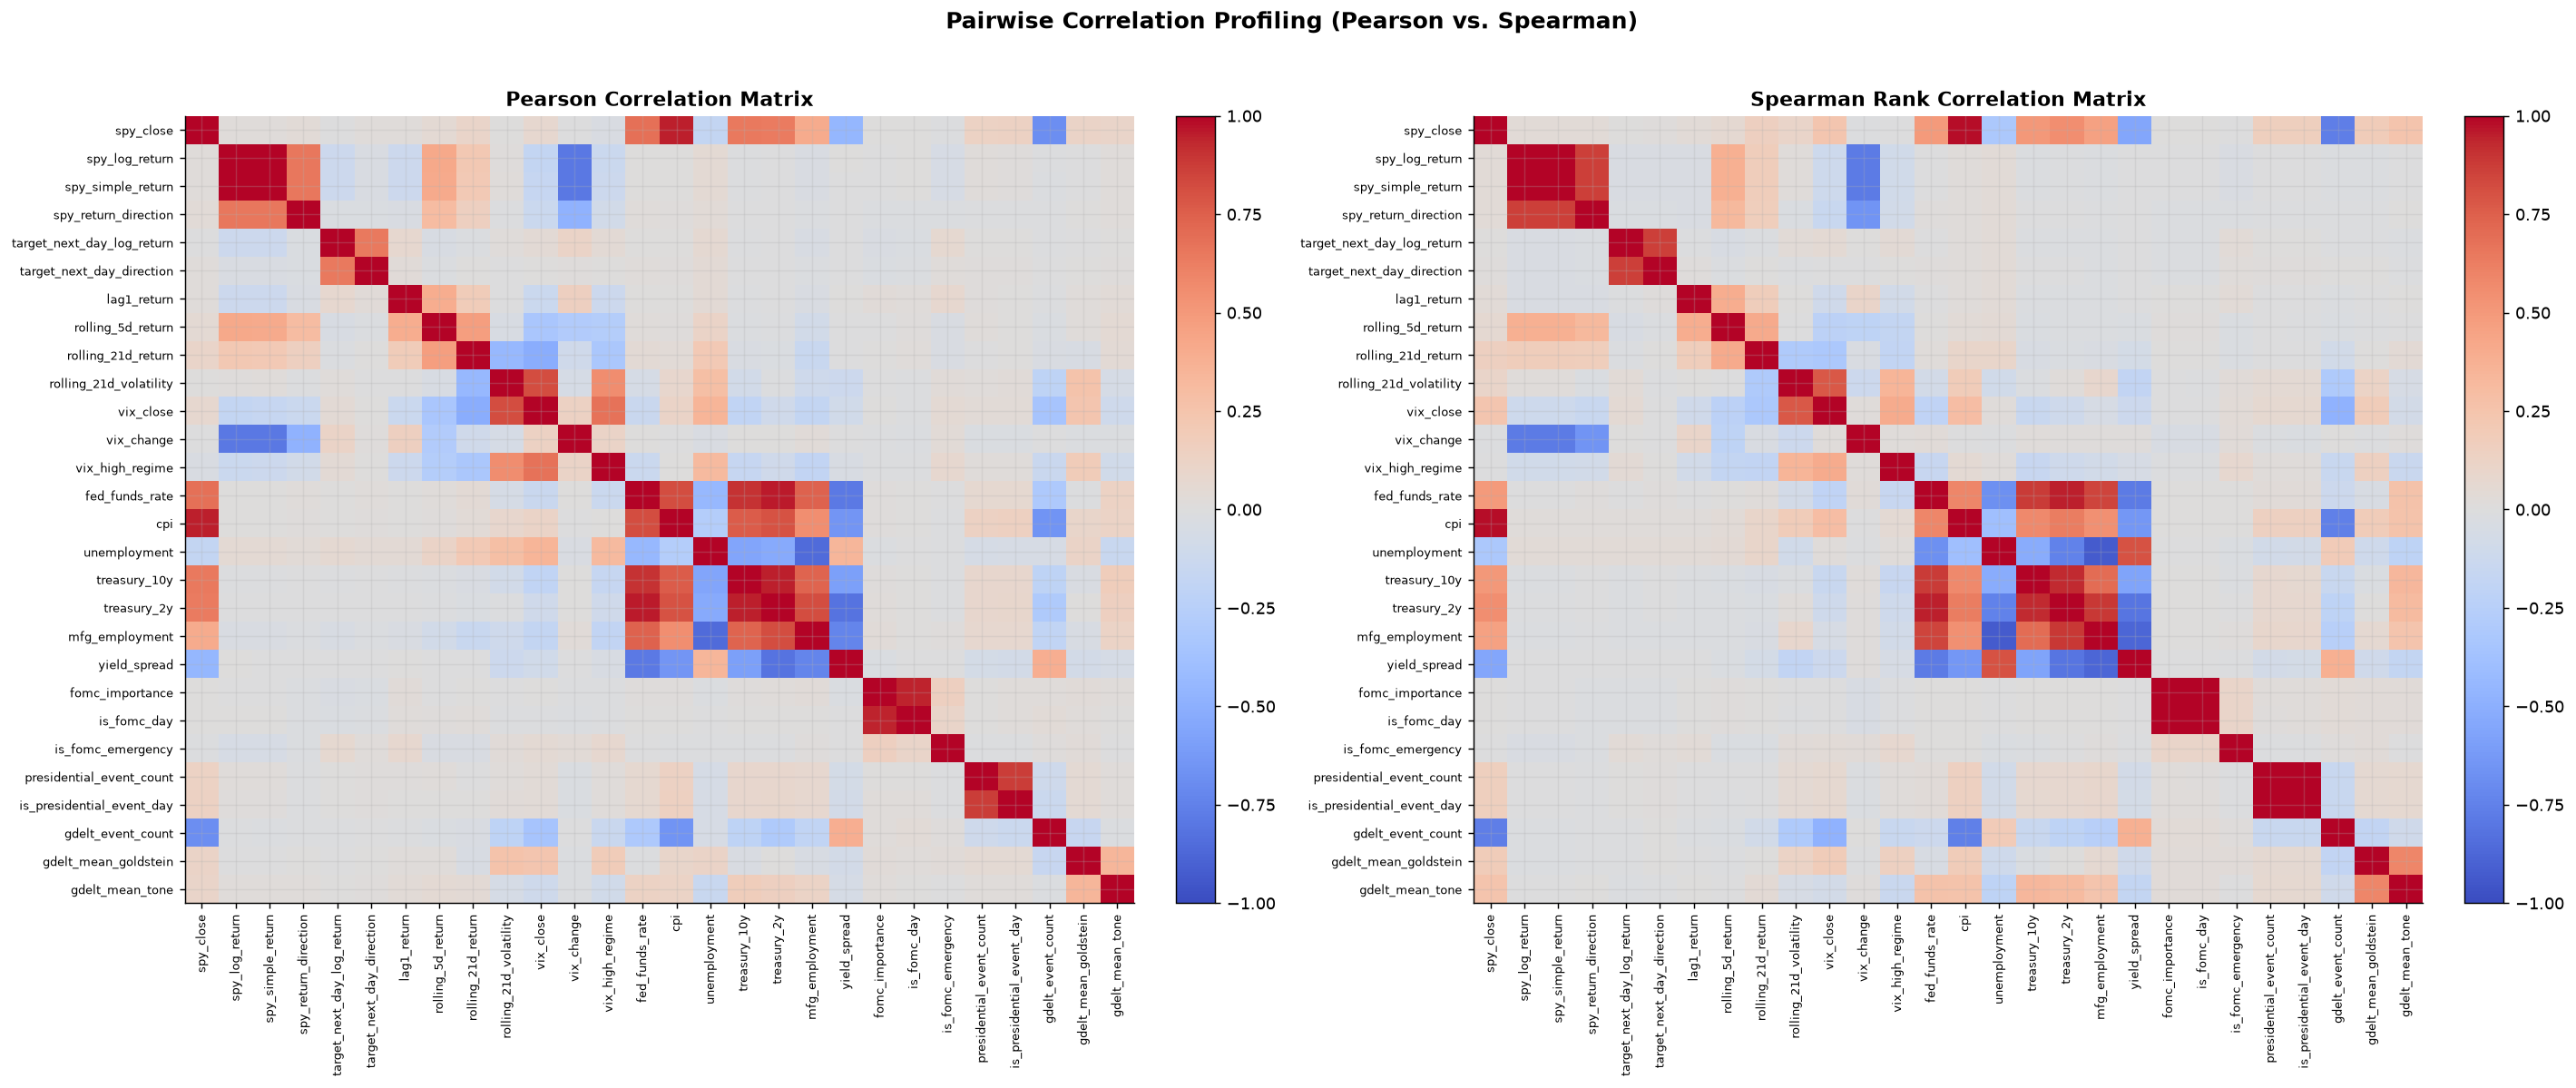

✓ Saved Figure 02r → /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02r_correlation_heatmap.png


In [17]:
# ── 10d. Figure 02r: Pearson vs Spearman Correlation Matrix ───────────────────

plot_cols = [c for c in master_df.columns if c not in ("date", "split") and pd.api.types.is_numeric_dtype(master_df[c])]
plot_cols = [c for c in plot_cols if not np.isclose(master_df[c].std(skipna=True), 0)]

sub = master_df[plot_cols]
pearson_full = sub.corr(method="pearson")
spearman_full = sub.corr(method="spearman")

# Save correlation tables
pearson_full.to_csv(TABLE_DIR / "02_correlation_pearson.csv")
spearman_full.to_csv(TABLE_DIR / "02_correlation_spearman.csv")

# Plot Heatmap
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

im1 = axes[0].imshow(pearson_full, vmin=-1, vmax=1, aspect="auto", cmap="coolwarm")
axes[0].set_title("Pearson Correlation Matrix", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(len(plot_cols)))
axes[0].set_yticks(range(len(plot_cols)))
axes[0].set_xticklabels(plot_cols, rotation=90, fontsize=7)
axes[0].set_yticklabels(plot_cols, fontsize=7)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(spearman_full, vmin=-1, vmax=1, aspect="auto", cmap="coolwarm")
axes[1].set_title("Spearman Rank Correlation Matrix", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(len(plot_cols)))
axes[1].set_yticks(range(len(plot_cols)))
axes[1].set_xticklabels(plot_cols, rotation=90, fontsize=7)
axes[1].set_yticklabels(plot_cols, fontsize=7)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Pairwise Correlation Profiling (Pearson vs. Spearman)", y=1.02, fontsize=14, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02r_correlation_heatmap.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Saved Figure 02r → {output_path}")

**Diagnostic Interpretations:**
1. **Volatility Clustering (`02p`):** Return volatility exhibits distinct temporal regimes (e.g., sharp 2020 COVID volatility spike followed by 2022 Fed rate hiking volatility). This validates the inclusion of 21-day rolling volatility and VIX interaction terms in feature engineering.
2. **Weak Linear Autocorrelation (`02q`):** ACF and PACF estimates quickly decay into the 95% confidence bounds within 2–3 lags. This indicates that simple autoregressive linear model features ($AR(p)$) alone cannot capture market dynamics, justifying the integration of non-linear event sentiment signals (FinBERT sentiment and GDELT geopolitical risk).

---
## 10.4 Section Summary — EDA Implementation & Pipeline Transition Strategy

The exploratory and empirical statistical analyses establish four core foundation results:

1. **Stationarity Validated:** Raw SPY close price levels are non-stationary ($p = 0.9960$), whereas daily continuous log returns ($\text{spy\_log\_return}$) are stationary ($p < 0.0001$). Continuous log returns serve as the official modeling target ($t+1$).
2. **Fat-Tailed Non-Gaussian Dynamics:** Return distributions display significant excess kurtosis ($14.64$) and negative skewness ($-0.59$), confirming fat tails and regime dependence that favor robust tree-based machine learning architectures.
3. **Event Density Confirmed:** Ingestion audits verify 89 high-impact FOMC policy announcements and 916 economic presidential communications (APP) across 2,743 trading days (2015–2025).
4. **Multicollinearity Handled:** Unnormalized level variables exhibit high pairwise correlation ($|r| > 0.90$), supporting the strategy of using differenced macro controls, normalized sentiment indices, and volatility ratios rather than raw levels in downstream feature engineering.

---
**Next Notebook:** `03_event_detection.ipynb` (FinBERT sentiment scoring of APP communications, daily event aggregation, and temporal leakage prevention).